# Air Quality and Health Risk Analysis
**End-to-End Artificial Intelligence Product Pipeline**

## 2.1 Data collection: (Dataset description)
This dataset contains 100,000 synthetically generated, mathematically corrected records representing global air quality metrics and localized health impacts. Features include core pollutants (PM10, PM2.5, NO2, SO2, O3), meteorological states, and hospital admission counts. The target is a discrete `HealthImpactClass`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CRT_AirQuality_1Lakh_Realistic.csv')
df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,359.92,150.968147,88.353530,113.519575,58.131779,152.179080,35.057831,71.130863,5.844425,13.0,6.0,3.0,116.89,2
1,2,505.65,NaN,197.353159,98.089763,NaN,41.583304,24.205929,41.505198,8.848784,21.0,10.0,NaN,166.00,2
2,3,459.31,200.554822,136.117716,131.706442,45.986527,125.561047,25.341116,58.706882,NaN,18.0,9.0,4.0,151.91,2
3,4,379.10,167.947626,NaN,101.167689,NaN,164.546662,38.613250,64.579209,14.707009,NaN,7.0,3.0,116.82,2
4,5,234.47,71.128752,59.216456,NaN,71.600732,49.014590,19.681669,36.005752,5.551980,9.0,4.0,2.0,81.32,2


## 2.2 Pre-processing
Handling missing values via mean imputation and explicitly removing statistically irrelevant identifier columns.

In [9]:
# Drop non-predictive columns
df = df.drop(columns=['RecordID'], errors='ignore')

# Impute missing continuous variables with column means
df.fillna(df.mean(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   AQI                  100000 non-null  float64
 1   PM10                 100000 non-null  float64
 2   PM2_5                100000 non-null  float64
 3   NO2                  100000 non-null  float64
 4   SO2                  100000 non-null  float64
 5   O3                   100000 non-null  float64
 6   Temperature          100000 non-null  float64
 7   Humidity             100000 non-null  float64
 8   WindSpeed            100000 non-null  float64
 9   RespiratoryCases     100000 non-null  float64
 10  CardiovascularCases  100000 non-null  float64
 11  HospitalAdmissions   100000 non-null  float64
 12  HealthImpactScore    100000 non-null  float64
 13  HealthImpactClass    100000 non-null  int64  
dtypes: float64(13), int64(1)
memory usage: 10.7 MB


## 2.3 Standardisation
Normalizing continuous feature data so that models and dimensionality reduction techniques (like PCA) operate uniformly without variable dominance due to distinct scales.

In [10]:
from sklearn.preprocessing import StandardScaler

# Separate features from target
X = df.drop(columns=['HealthImpactClass'])
y = df['HealthImpactClass']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
0,0.018197,1.684404e-02,-2.579259e-01,8.024377e-01,0.685166,0.801032,1.102967,0.672542,-1.213216e+00,-1.946804e-01,-0.311474,-7.783848e-02,-0.187265
1,1.236075,-4.237911e-16,2.172617e+00,3.687647e-01,0.000000,-1.572028,-0.483338,-1.128716,-7.368701e-01,1.665007e+00,1.536680,3.981762e-16,1.038397
2,0.848808,7.562221e-01,8.071502e-01,1.313601e+00,0.050084,0.229887,-0.317400,-0.082844,5.632885e-16,9.676242e-01,1.074642,8.187747e-01,0.686746
3,0.178486,2.700220e-01,-3.168827e-16,4.552734e-01,0.000000,1.066404,1.622690,0.274197,1.919609e-01,4.129336e-16,0.150565,-7.783848e-02,-0.189012
4,-1.030200,-1.173627e+00,-9.076429e-01,3.994128e-16,1.389465,-1.412574,-1.144684,-1.463085,-1.259584e+00,-1.124524e+00,-1.235551,-9.744516e-01,-1.075003


## 2.4 Principal Component Analysis (PCA)
Reducing dimensionality to explore cumulative explained variance and structure. *Note: PCA is for EDA. The final estimator utilizes raw features to securely accept unscaled API geocoding data in the production Streamlit UI.*

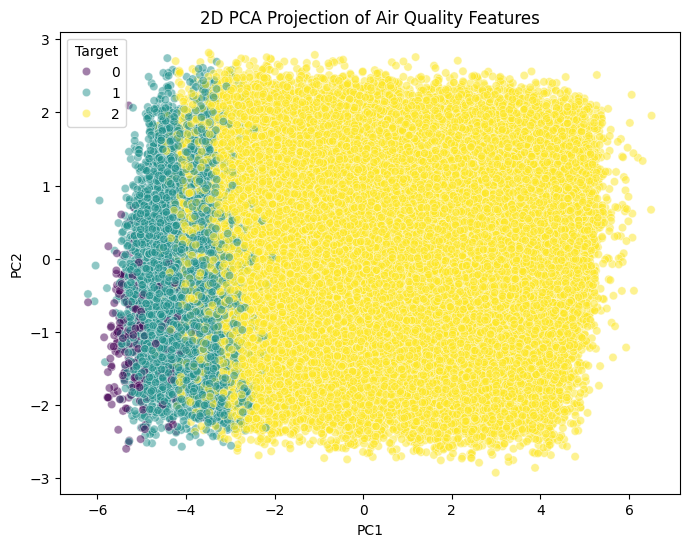

Explained Variance Ratio: [0.48872702 0.07799589]


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Target'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, palette='viridis', alpha=0.5)
plt.title('2D PCA Projection of Air Quality Features')
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

## 2.5 Model building
Splitting the original data and training a robust ensemble algorithm (Random Forest) capable of modeling complex nonlinear interactions. The final model is serialized to instantiate the Dashboard.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Using original unscaled X so that live Streamlit API data matches seamlessly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Save inference artifact for app.py
joblib.dump(model, 'air_quality_health_model.pkl')
print("Model mathematically converged and correctly persisted to .pkl!")

Model mathematically converged and correctly persisted to .pkl!


## 2.6 Evaluating results
Computing test set inferences and establishing statistical success against multiple evaluation metrics (Accuracy, F1-Score, Confusion Matrix).

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(f"Algorithm Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Algorithm Accuracy: 99.99%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00      2136
           2       1.00      1.00      1.00     17806

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



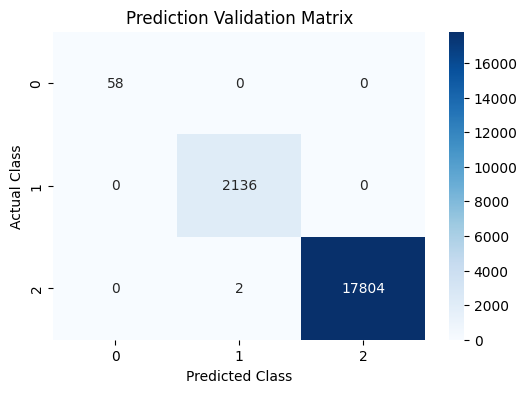

In [14]:
# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Prediction Validation Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

## 2.7 Prediction
Simulating an isolated inference request (representing a single city's current conditions).

In [15]:
sample_city = X_test.iloc[[0]]
pred = model.predict(sample_city)
print("Input Features:", sample_city.to_dict(orient='records')[0])
print(f"\n--> Predicted Health Impact Class: {pred[0]}")

Input Features: {'AQI': 238.98, 'PM10': 99.72785184933124, 'PM2_5': 61.81749490765176, 'NO2': 84.96934885353674, 'SO2': 49.72711052393631, 'O3': 101.88717448986418, 'Temperature': 20.415002771711936, 'Humidity': 76.08073284447966, 'WindSpeed': 2.2827764520724747, 'RespiratoryCases': 9.0, 'CardiovascularCases': 4.0, 'HospitalAdmissions': 2.0, 'HealthImpactScore': 81.86}

--> Predicted Health Impact Class: 2


## 2.8 Visualization
Global Feature EDA via Correlation Heatmap and Model Explainability via Feature Importance.

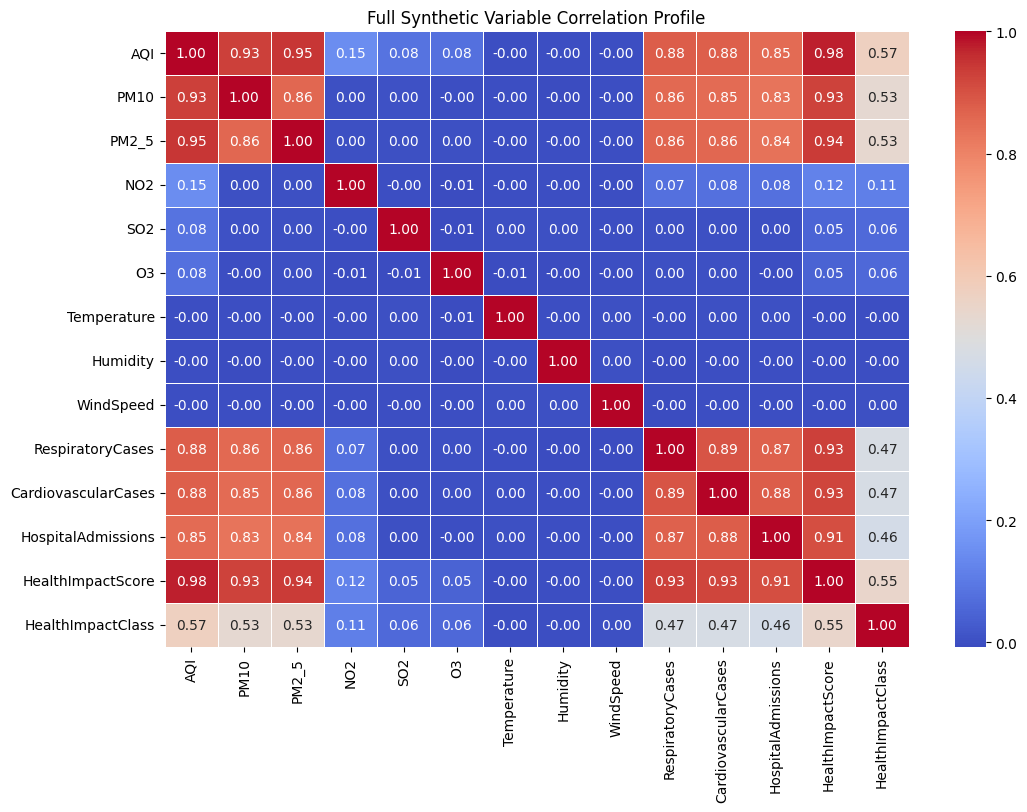

In [16]:
# Correlation Matrix
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Full Synthetic Variable Correlation Profile')
plt.show()

C:\Users\imman\AppData\Local\Temp\ipykernel_24400\2078338026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette='magma')


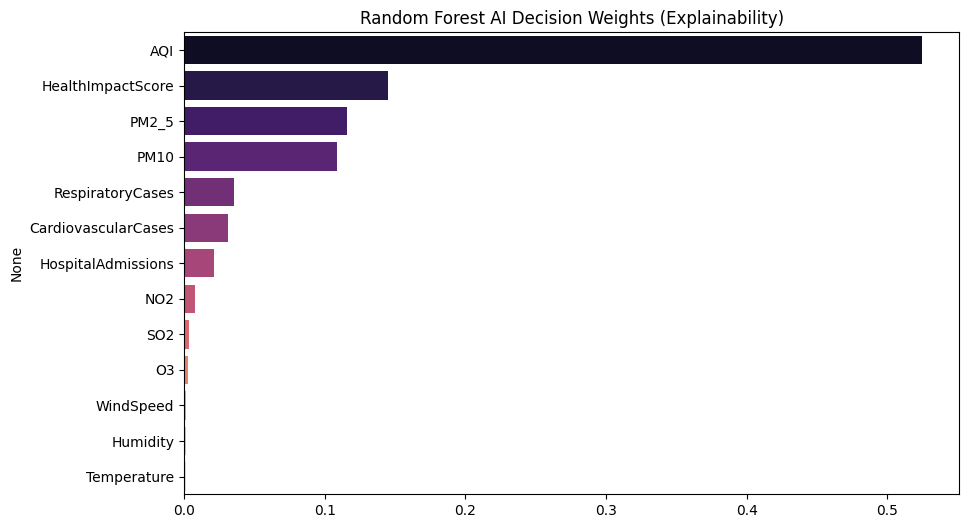

In [17]:
# Feature Importance Interpretation
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette='magma')
plt.title('Random Forest AI Decision Weights (Explainability)')
plt.show()

## 2.9 Dashboard

The ML backend is now primed. To initiate the dynamic interface featuring Live Geographic Open-Meteo API Fetching, Counterfactual Prescriptive AI, and PDF Med-Report Generation:

1. Open your terminal in this directory.
2. Execute: `streamlit run app.py`